In [16]:
# CELL 1 — Install
# ────────────────────────────────────────────────────────────────

!pip install albumentations --quiet

In [17]:
# CELL 2 — Imports
# ────────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import numpy as np
from PIL import Image
import os
import datetime

import matplotlib.pyplot as plt
import seaborn as sns

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    jaccard_score, accuracy_score,
    confusion_matrix, classification_report
)

from torchsummary import summary
from scipy import ndimage

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"All libraries imported.")
print(f"Device : {device}")
# if torch.cuda.is_available():
#     print(f"GPU    : {torch.cuda.get_device_name(0)}")



All libraries imported.
Device : cuda


In [18]:
# ────────────────────────────────────────────────────────────────
# CELL 3 — Attention U-Net Architecture
# ────────────────────────────────────────────────────────────────

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g,   F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l,   F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1,     kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1  = self.W_g(g)
        x1  = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class AttentionUNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()

        def double_conv(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        self.enc1 = double_conv(n_channels, 64)
        self.enc2 = double_conv(64,  128)
        self.enc3 = double_conv(128, 256)
        self.enc4 = double_conv(256, 512)
        self.pool = nn.MaxPool2d(2)

        self.upsample = nn.Upsample(
            scale_factor=2, mode="bilinear", align_corners=True
        )

        self.att3 = AttentionGate(F_g=512, F_l=256, F_int=128)
        self.att2 = AttentionGate(F_g=256, F_l=128, F_int=64)
        self.att1 = AttentionGate(F_g=128, F_l=64,  F_int=32)

        self.dec3 = double_conv(512 + 256, 256)
        self.dec2 = double_conv(256 + 128, 128)
        self.dec1 = double_conv(128 + 64,  64)

        self.out_conv = nn.Conv2d(64, n_classes, kernel_size=1)
        self._initialize_weights()

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Decoder + Attention (positional args — fixes torchsummary bug)
        d3 = self.upsample(e4)
        e3 = self.att3(d3, e3)   # ← fixed
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.upsample(d3)
        e2 = self.att2(d2, e2)   # ← fixed
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.upsample(d2)
        e1 = self.att1(d1, e1)   # ← fixed
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

print(" Attention U-Net defined.")


 Attention U-Net defined.


In [19]:
# ────────────────────────────────────────────────────────────────
# CELL 4 — Model Summary
# ────────────────────────────────────────────────────────────────

_model_check = AttentionUNet(n_channels=3, n_classes=1).to(device)
summary(_model_check, input_size=(3, 256, 256))
del _model_check


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,792
       BatchNorm2d-2         [-1, 64, 256, 256]             128
              ReLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,928
       BatchNorm2d-5         [-1, 64, 256, 256]             128
              ReLU-6         [-1, 64, 256, 256]               0
         MaxPool2d-7         [-1, 64, 128, 128]               0
            Conv2d-8        [-1, 128, 128, 128]          73,856
       BatchNorm2d-9        [-1, 128, 128, 128]             256
             ReLU-10        [-1, 128, 128, 128]               0
           Conv2d-11        [-1, 128, 128, 128]         147,584
      BatchNorm2d-12        [-1, 128, 128, 128]             256
             ReLU-13        [-1, 128, 128, 128]               0
        MaxPool2d-14          [-1, 128,

In [20]:
# ────────────────────────────────────────────────────────────────
# CELL 5 — Data Augmentation
# Same as U-Net notebook — fair comparison
# ────────────────────────────────────────────────────────────────

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

print(" Transforms defined.")



 Transforms defined.


In [21]:
# CELL 6 — Dataset Class
# Same as U-Net notebook — fair comparison
# ────────────────────────────────────────────────────────────────

class PolypDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform
        self.images    = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name  = self.images[idx]
        img_path  = os.path.join(self.img_dir,  img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found: {img_name}")

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"))

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"]

        mask = mask.unsqueeze(0).float()
        mask = (mask > 0).float()
        return image, mask

print(" PolypDataset defined.")


 PolypDataset defined.


In [27]:
# CELL 7 — Dataset Split
# seed=42 — SAME split as U-Net → fair comparison
# ────────────────────────────────────────────────────────────────

IMAGE_DIR = "/kaggle/input/datasets/thasleema03/colorectal-polyp-segmentation-dataset/polyp_dataset/images"
MASK_DIR  = "/kaggle/input/datasets/thasleema03/colorectal-polyp-segmentation-dataset/polyp_dataset/masks"

temp_dataset = PolypDataset(IMAGE_DIR, MASK_DIR)
total_size   = len(temp_dataset)
train_size   = int(0.8 * total_size)
val_size     = total_size - train_size

generator = torch.Generator().manual_seed(42)   # same seed as U-Net

train_indices, val_indices = torch.utils.data.random_split(
    range(total_size), [train_size, val_size], generator=generator
)
train_indices = list(train_indices)
val_indices   = list(val_indices)

train_full    = PolypDataset(IMAGE_DIR, MASK_DIR, transform=train_transform)
val_full      = PolypDataset(IMAGE_DIR, MASK_DIR, transform=val_transform)
train_dataset = Subset(train_full, train_indices)
val_dataset   = Subset(val_full,   val_indices)

BATCH_SIZE   = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0,
                          pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0,
                          pin_memory=torch.cuda.is_available())

print("  Dataset split complete.")
print(f"   Total   : {total_size}")
print(f"   Train   : {len(train_dataset)}")
print(f"   Val     : {len(val_dataset)}")



  Dataset split complete.
   Total   : 1000
   Train   : 800
   Val     : 200


In [28]:
# CELL 8 — Loss Function
# Same as U-Net notebook — fair comparison
# ────────────────────────────────────────────────────────────────

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds   = torch.sigmoid(preds)
        preds   = preds.view(preds.size(0), -1)
        targets = targets.view(targets.size(0), -1)
        intersection = (preds * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (
            preds.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )
        return 1.0 - dice.mean()


class DiceBCELoss(nn.Module):
    def __init__(self, pos_weight=3.0):
        super().__init__()
        self.dice_fn    = DiceLoss()
        self.pos_weight = pos_weight

    def forward(self, preds, targets):
        pw        = torch.tensor([self.pos_weight], device=preds.device)
        bce_loss  = nn.functional.binary_cross_entropy_with_logits(
            preds, targets, pos_weight=pw
        )
        dice_loss = self.dice_fn(preds, targets)
        return 0.8 * dice_loss + 0.2 * bce_loss


criterion = DiceBCELoss(pos_weight=3.0).to(device)
print("   DiceBCELoss defined.")
print("   0.8×Dice + 0.2×BCE | pos_weight=3.0")


   DiceBCELoss defined.
   0.8×Dice + 0.2×BCE | pos_weight=3.0


In [29]:
# CELL 9 — Model Initialization
# ────────────────────────────────────────────────────────────────

MODEL_SAVE_PATH = "/kaggle/working/attention_unet_model.pth"

model     = AttentionUNet(n_channels=3, n_classes=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

print("  Attention U-Net initialized.")
print(f"   Parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"   LR         : {optimizer.param_groups[0]['lr']}")


  Attention U-Net initialized.
   Parameters : 7,918,695
   LR         : 0.0001


In [30]:
# CELL 10 — Training Loop
# Set TRAIN_MODEL=False after first training
# ────────────────────────────────────────────────────────────────

TRAIN_MODEL     = True
MODEL_SAVE_PATH = "/kaggle/working/attention_unet_model.pth"
NUM_EPOCHS      = 25

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_loss = float("inf")

if TRAIN_MODEL:
    print(" Starting Attention U-Net training...\n")

    for epoch in range(NUM_EPOCHS):

        # Train
        model.train()
        running_loss = 0.0
        correct = 0
        total   = 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            preds    = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == masks).sum().item()
            total   += masks.numel()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc  = 100.0 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        model.eval()
        val_loss_sum = 0.0
        val_correct  = 0
        val_total    = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                outputs = model(imgs)
                loss    = criterion(outputs, masks)
                val_loss_sum += loss.item() * imgs.size(0)
                preds        = (torch.sigmoid(outputs) > 0.5).float()
                val_correct  += (preds == masks).sum().item()
                val_total    += masks.numel()

        val_loss = val_loss_sum / len(val_loader.dataset)
        val_acc  = 100.0 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        prev_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        curr_lr = optimizer.param_groups[0]['lr']
        if curr_lr != prev_lr:
            print(f"   LR: {prev_lr:.6f} → {curr_lr:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"    BEST SAVED")

        print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}]")
        print(f"   Train → Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
        print(f"   Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")
        print("-" * 50)

    print(f"\n Training complete. Best val loss: {best_val_loss:.4f}")
    print(f"   Saved: {MODEL_SAVE_PATH}")

else:
    print("  Training skipped (TRAIN_MODEL=False)")



 Starting Attention U-Net training...

    BEST SAVED
Epoch [01/25]
   Train → Loss: 0.6560 | Acc: 73.30%
   Val   → Loss: 0.5981 | Acc: 74.44%
--------------------------------------------------
Epoch [02/25]
   Train → Loss: 0.6003 | Acc: 79.45%
   Val   → Loss: 0.5992 | Acc: 83.60%
--------------------------------------------------
    BEST SAVED
Epoch [03/25]
   Train → Loss: 0.5727 | Acc: 81.43%
   Val   → Loss: 0.5289 | Acc: 82.50%
--------------------------------------------------
    BEST SAVED
Epoch [04/25]
   Train → Loss: 0.5559 | Acc: 82.49%
   Val   → Loss: 0.5214 | Acc: 81.01%
--------------------------------------------------
    BEST SAVED
Epoch [05/25]
   Train → Loss: 0.5262 | Acc: 84.50%
   Val   → Loss: 0.5039 | Acc: 85.23%
--------------------------------------------------
Epoch [06/25]
   Train → Loss: 0.5120 | Acc: 85.33%
   Val   → Loss: 0.5160 | Acc: 87.56%
--------------------------------------------------
Epoch [07/25]
   Train → Loss: 0.4954 | Acc: 86.15%
   

In [32]:
# CELL 11 — Load Trained Model
# Checks working dir first, then Kaggle dataset input
# ────────────────────────────────────────────────────────────────

CANDIDATE_PATHS = [
    "/kaggle/working/attention_unet_model.pth",
    "/kaggle/input/polyp-attention-unet/attention_unet_model.pth",
]

MODEL_PATH = None
for path in CANDIDATE_PATHS:
    if os.path.exists(path):
        MODEL_PATH = path
        break

# if MODEL_PATH is None:
#     raise FileNotFoundError(
#         " Model not found.\n"
#         "   Set TRAIN_MODEL=True in Cell 10 and retrain."
#     )

model = AttentionUNet(n_channels=3, n_classes=1).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"   Attention U-Net loaded.")
print(f"   Path : {MODEL_PATH}")
print(f"   Size : {size_mb:.1f} MB")


   Attention U-Net loaded.
   Path : /kaggle/working/attention_unet_model.pth
   Size : 30.3 MB


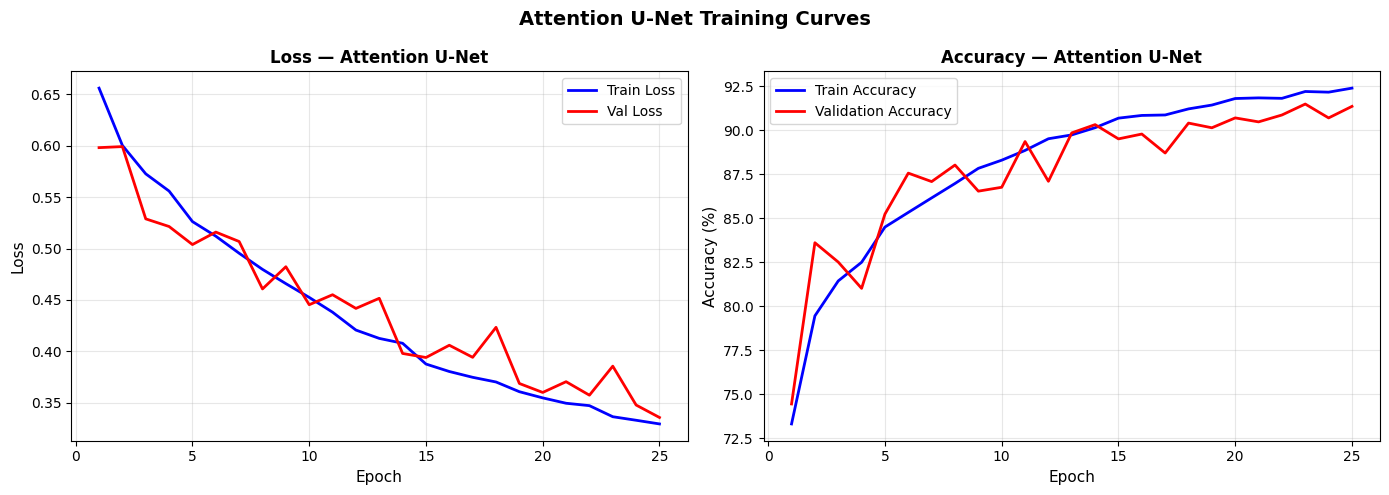

Training curves saved successfully.


In [34]:
# CELL 12 — Training Curves
# ────────────────────────────────────────────────────────────────

if len(train_losses) > 0:
    epochs = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Loss Curve ----
    axes[0].plot(epochs, train_losses,
                 color="blue", linestyle="-", linewidth=2,
                 label="Train Loss")
    axes[0].plot(epochs, val_losses,
                 color="red", linestyle="-", linewidth=2,
                 label="Val Loss")

    axes[0].set_xlabel("Epoch", fontsize=11)
    axes[0].set_ylabel("Loss", fontsize=11)
    axes[0].set_title("Loss — Attention U-Net", fontsize=12, fontweight="bold")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ---- Accuracy Curve ----
    axes[1].plot(epochs, train_accs,
                 color="blue", linestyle="-", linewidth=2,
                 label="Train Accuracy")
    axes[1].plot(epochs, val_accs,
                 color="red", linestyle="-", linewidth=2,
                 label="Validation Accuracy")

    axes[1].set_xlabel("Epoch", fontsize=11)
    axes[1].set_ylabel("Accuracy (%)", fontsize=11)
    axes[1].set_title("Accuracy — Attention U-Net", fontsize=12, fontweight="bold")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("Attention U-Net Training Curves",
                 fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.savefig("attention_unet_training_curves.png",
                dpi=300, bbox_inches="tight")
    plt.show()

    print("Training curves saved successfully.")
else:
    print("No training history — model loaded from file.")

In [35]:
# CELL 13 — Helper Functions
# THRESHOLD=0.40 — same as U-Net for fair comparison
# ────────────────────────────────────────────────────────────────

THRESHOLD = 0.40
MIN_BLOB  = 300

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3)


def denormalize(tensor):
    img = tensor.cpu().permute(1, 2, 0)
    img = img * STD + MEAN
    return img.clamp(0, 1).numpy()


def remove_small_blobs(pred_np, min_size=300):
    labeled, n = ndimage.label(pred_np)
    cleaned    = pred_np.copy()
    for i in range(1, n + 1):
        if (labeled == i).sum() < min_size:
            cleaned[labeled == i] = 0
    return cleaned


def get_all_preds_targets(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            preds   = (torch.sigmoid(outputs) > THRESHOLD).float()
            for i in range(preds.size(0)):
                pred_np = preds[i].cpu().squeeze().numpy()
                pred_np = remove_small_blobs(pred_np, MIN_BLOB)
                all_preds.append(pred_np.flatten())
                all_targets.append(
                    masks[i].cpu().squeeze().numpy().flatten()
                )
    preds_np   = np.concatenate(all_preds).astype(np.uint8)
    targets_np = np.concatenate(all_targets).astype(np.uint8)
    return preds_np, targets_np


print("   Helper functions ready.")
print(f"   THRESHOLD : {THRESHOLD}")
print(f"   MIN_BLOB  : {MIN_BLOB} px")



   Helper functions ready.
   THRESHOLD : 0.4
   MIN_BLOB  : 300 px


In [37]:
# CELL 14 — Segmentation Metrics
# ────────────────────────────────────────────────────────────────

val_preds, val_targets = get_all_preds_targets(model, val_loader)

precision = precision_score(val_targets, val_preds, zero_division=0)
recall    = recall_score(val_targets, val_preds, zero_division=0)
f1        = f1_score(val_targets, val_preds, zero_division=0)
iou       = jaccard_score(val_targets, val_preds,
                          average="binary", zero_division=0)
acc       = accuracy_score(val_targets, val_preds)

print("=" * 45)
print("   ATTENTION U-NET — SEGMENTATION METRICS")
print("=" * 45)
print(f"{'Metric':<15} {'Value':>10}")
print("-" * 30)
print(f"{'Precision':<15} {precision:>10.4f}")
print(f"{'Recall':<15} {recall:>10.4f}")
print(f"{'F1-Score':<15} {f1:>10.4f}")
print(f"{'IoU':<15} {iou:>10.4f}")
print(f"{'Accuracy':<15} {acc:>10.4f}")
print("=" * 45)

   ATTENTION U-NET — SEGMENTATION METRICS
Metric               Value
------------------------------
Precision           0.7384
Recall              0.7722
F1-Score            0.7550
IoU                 0.6064
Accuracy            0.9130


In [38]:
# CELL 15 — Classification Report
# ────────────────────────────────────────────────────────────────

print("CLASSIFICATION REPORT — Attention U-Net")
print("=" * 50)
print(classification_report(
    val_targets, val_preds,
    target_names=["Background", "Polyp"],
    digits=4, zero_division=0
))


CLASSIFICATION REPORT — Attention U-Net
              precision    recall  f1-score   support

  Background     0.9517    0.9426    0.9471  10832216
       Polyp     0.7384    0.7722    0.7550   2274984

    accuracy                         0.9130  13107200
   macro avg     0.8451    0.8574    0.8510  13107200
weighted avg     0.9147    0.9130    0.9138  13107200



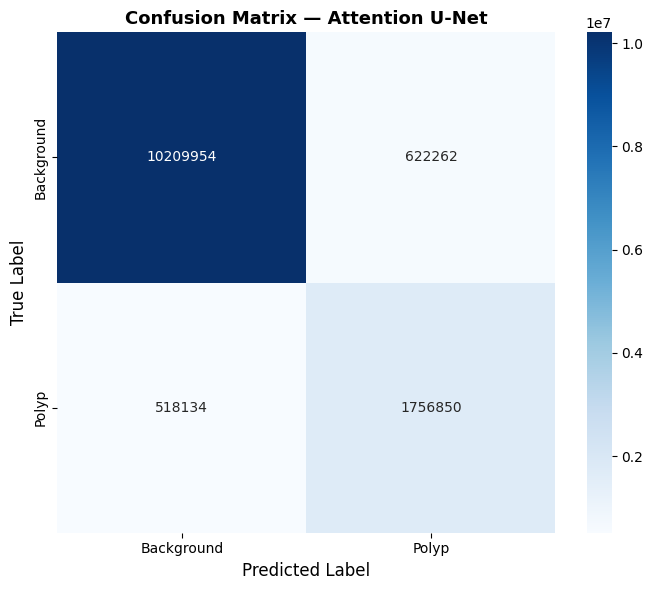

ATTENTION U-NET — CONFUSION MATRIX
True Negatives : 10,209,954
True Positives : 1,756,850
False Positives: 622,262
False Negatives: 518,134


In [41]:
# CELL 16 — Confusion Matrix
# ────────────────────────────────────────────────────────────────

cm = confusion_matrix(val_targets, val_preds, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",   # Changed to Blue
    xticklabels=["Background", "Polyp"],
    yticklabels=["Background", "Polyp"],
    cbar=True,
    ax=ax
)

ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — Attention U-Net",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("attention_unet_confusion_matrix.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("=" * 40)
print("ATTENTION U-NET — CONFUSION MATRIX")
print("=" * 40)
print(f"True Negatives : {tn:,}")
print(f"True Positives : {tp:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print("=" * 40)

   ATTENTION U-NET — PER-SAMPLE IoU
Mean IoU : 0.6273
Std Dev  : 0.2202
Min IoU  : 0.0783
Max IoU  : 0.9634


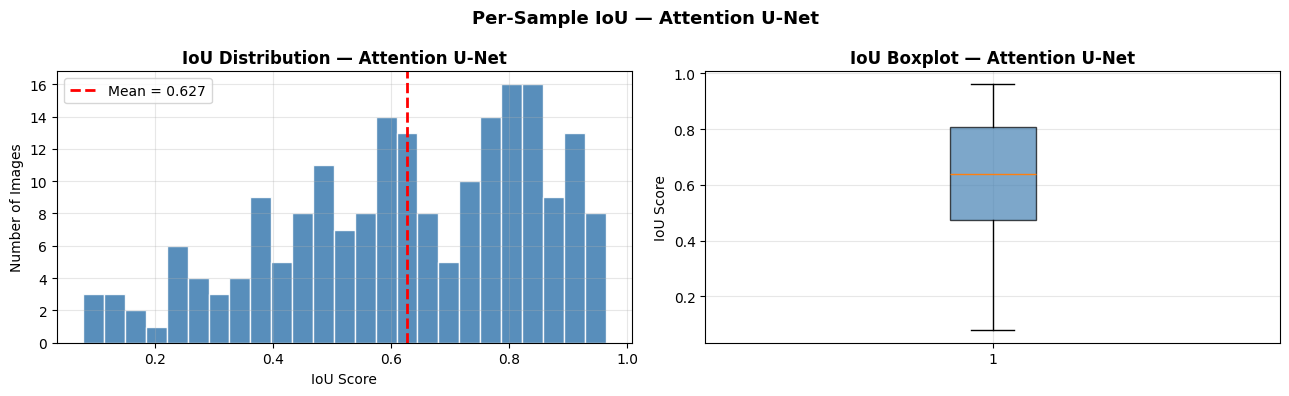

IoU distribution saved successfully.


In [43]:
# CELL 17 — Per-Sample IoU Analysis
# ────────────────────────────────────────────────────────────────

model.eval()
sample_ious = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds   = (torch.sigmoid(outputs) > THRESHOLD).float()

        for i in range(preds.size(0)):
            pred_np = preds[i].cpu().squeeze().numpy()
            pred_np = remove_small_blobs(pred_np, MIN_BLOB)
            mask_np = masks[i].cpu().squeeze().numpy()

            intersection = (pred_np * mask_np).sum()
            union        = (pred_np + mask_np).sum() - intersection
            iou_val      = 1.0 if union == 0 else intersection / union

            sample_ious.append(iou_val)

sample_ious = np.array(sample_ious)

print("=" * 45)
print("   ATTENTION U-NET — PER-SAMPLE IoU")
print("=" * 45)
print(f"Mean IoU : {sample_ious.mean():.4f}")
print(f"Std Dev  : {sample_ious.std():.4f}")
print(f"Min IoU  : {sample_ious.min():.4f}")
print(f"Max IoU  : {sample_ious.max():.4f}")
print("=" * 45)

# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(sample_ious, bins=25,
             color="steelblue",
             edgecolor="white",
             alpha=0.9)

axes[0].axvline(sample_ious.mean(),
                color="red",
                linestyle="--",
                linewidth=2,
                label=f"Mean = {sample_ious.mean():.3f}")

axes[0].set_xlabel("IoU Score")
axes[0].set_ylabel("Number of Images")
axes[0].set_title("IoU Distribution — Attention U-Net",
                  fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(sample_ious,
                patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))

axes[1].set_ylabel("IoU Score")
axes[1].set_title("IoU Boxplot — Attention U-Net",
                  fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Per-Sample IoU — Attention U-Net",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("attention_unet_iou_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("IoU distribution saved successfully.")

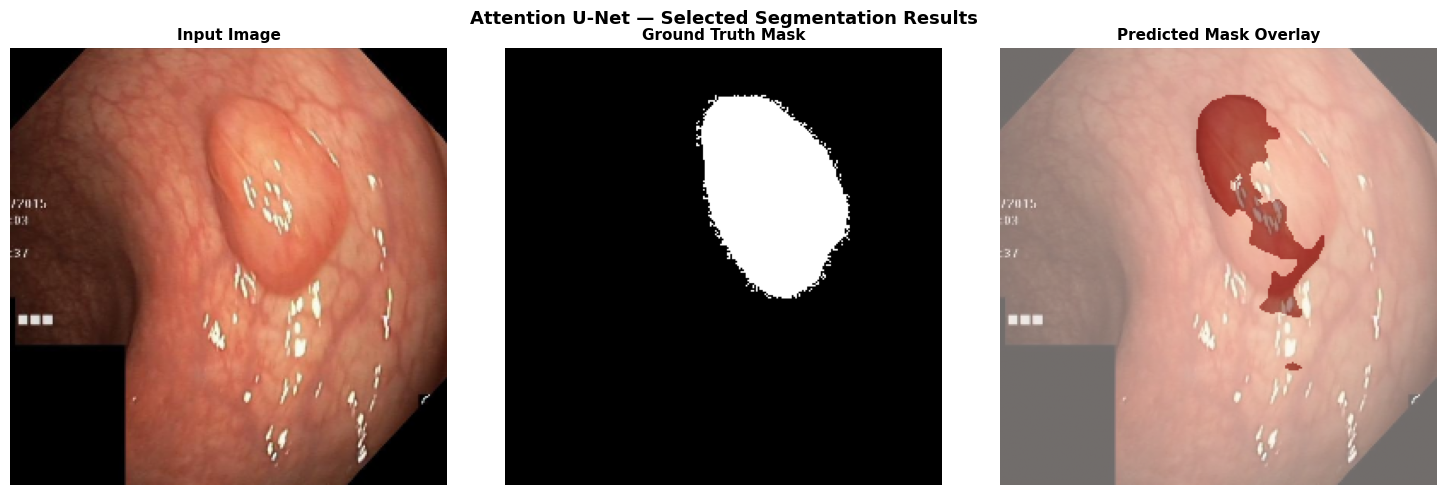

Visualization saved to segmentation_results_selected.png


In [47]:
# SELECTED VISUALIZATION — Attention U-Net
# ================================================================

SELECTED_INDICES = [10]   # change indices as needed (0-indexed)

model.eval()

selected_imgs, selected_masks, selected_preds = [], [], []

with torch.no_grad():
    for idx in SELECTED_INDICES:
        img, mask = val_dataset[idx]

        img_t  = img.unsqueeze(0).to(device)   # [1, 3, H, W]
        mask_t = mask.unsqueeze(0).to(device)  # [1, 1, H, W]

        output = model(img_t)
        pred   = (torch.sigmoid(output) > 0.5).float()

        selected_imgs.append(img_t[0])
        selected_masks.append(mask_t[0])
        selected_preds.append(pred[0])

num_show = len(SELECTED_INDICES)
fig, axes = plt.subplots(num_show, 3, figsize=(15, 5 * num_show))

if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_show):
    img_disp = denormalize(selected_imgs[i])
    mask_np  = selected_masks[i].cpu().squeeze().numpy()
    pred_np  = selected_preds[i].cpu().squeeze().numpy()

    # Per-image IoU
    intersection = (pred_np * mask_np).sum()
    union        = (pred_np + mask_np).sum() - intersection
    img_iou      = 1.0 if union == 0 else intersection / union

    # Column 1: Input
    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title("Input Image",                          # FIX 1: removed stray )
                          fontsize=11, fontweight="bold")
    axes[i, 0].set_xlabel(f"IoU: {img_iou:.3f}",
                           fontsize=10,
                           color="green" if img_iou > 0.5 else "red")
    axes[i, 0].axis("off")

    # Column 2: Ground Truth
    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask", fontsize=11, fontweight="bold")
    axes[i, 1].axis("off")

    # Column 3: Prediction Overlay
    axes[i, 2].imshow(img_disp)
    axes[i, 2].imshow(pred_np, cmap="Reds", alpha=0.45)
    axes[i, 2].set_title("Predicted Mask Overlay", fontsize=11, fontweight="bold")
    axes[i, 2].axis("off")

plt.suptitle("Attention U-Net — Selected Segmentation Results",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("segmentation_results_selected.png", dpi=300, bbox_inches="tight")
plt.show()                                                        # FIX 2: separate line
print("Visualization saved to segmentation_results_selected.png")





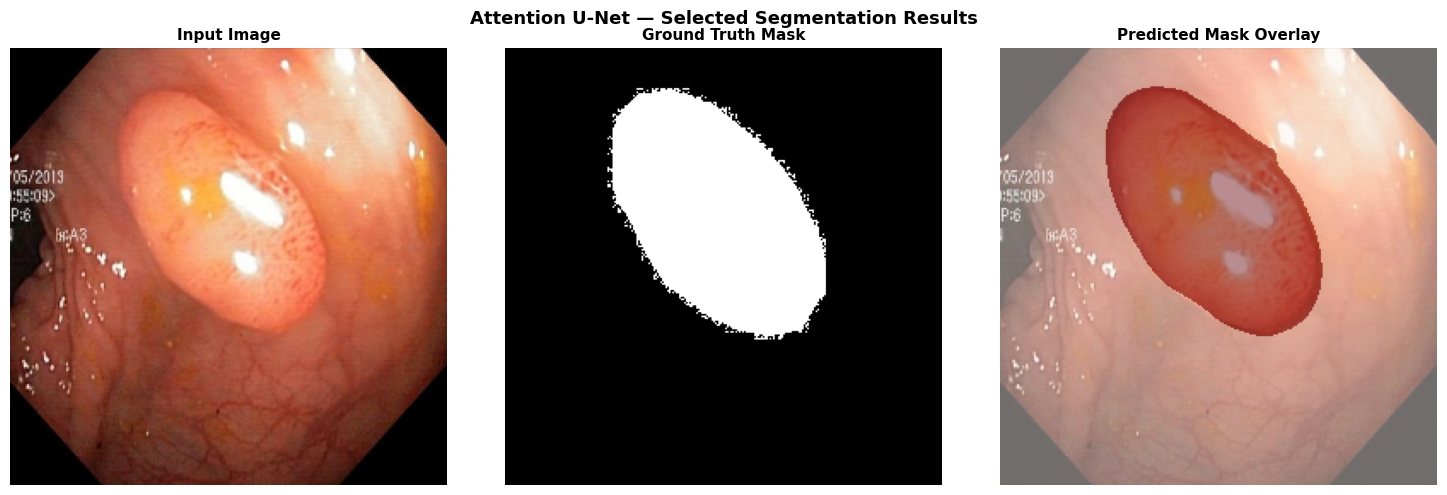

Visualization saved to segmentation_results_selected.png


In [48]:
# SELECTED VISUALIZATION — Attention U-Net
# ================================================================

SELECTED_INDICES = [4]   # change indices as needed (0-indexed)

model.eval()

selected_imgs, selected_masks, selected_preds = [], [], []

with torch.no_grad():
    for idx in SELECTED_INDICES:
        img, mask = val_dataset[idx]

        img_t  = img.unsqueeze(0).to(device)   # [1, 3, H, W]
        mask_t = mask.unsqueeze(0).to(device)  # [1, 1, H, W]

        output = model(img_t)
        pred   = (torch.sigmoid(output) > 0.5).float()

        selected_imgs.append(img_t[0])
        selected_masks.append(mask_t[0])
        selected_preds.append(pred[0])

num_show = len(SELECTED_INDICES)
fig, axes = plt.subplots(num_show, 3, figsize=(15, 5 * num_show))

if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_show):
    img_disp = denormalize(selected_imgs[i])
    mask_np  = selected_masks[i].cpu().squeeze().numpy()
    pred_np  = selected_preds[i].cpu().squeeze().numpy()

    # Per-image IoU
    intersection = (pred_np * mask_np).sum()
    union        = (pred_np + mask_np).sum() - intersection
    img_iou      = 1.0 if union == 0 else intersection / union

    # Column 1: Input
    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title("Input Image",                          # FIX 1: removed stray )
                          fontsize=11, fontweight="bold")
    axes[i, 0].set_xlabel(f"IoU: {img_iou:.3f}",
                           fontsize=10,
                           color="green" if img_iou > 0.5 else "red")
    axes[i, 0].axis("off")

    # Column 2: Ground Truth
    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask", fontsize=11, fontweight="bold")
    axes[i, 1].axis("off")

    # Column 3: Prediction Overlay
    axes[i, 2].imshow(img_disp)
    axes[i, 2].imshow(pred_np, cmap="Reds", alpha=0.45)
    axes[i, 2].set_title("Predicted Mask Overlay", fontsize=11, fontweight="bold")
    axes[i, 2].axis("off")

plt.suptitle("Attention U-Net — Selected Segmentation Results",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("segmentation_results_selected.png", dpi=300, bbox_inches="tight")
plt.show()                                                        # FIX 2: separate line
print("Visualization saved to segmentation_results_selected.png")





In [49]:
# CELL 19 — Save Metrics Report
# Includes U-Net reference values for direct comparison
# ────────────────────────────────────────────────────────────────

REPORT_PATH = "/kaggle/working/attention_unet_metrics_report.txt"
timestamp   = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

report_lines = [
    "ATTENTION U-NET — COMPLETE METRICS REPORT",
    "=" * 52,
    f"Generated    : {timestamp}",
    f"Architecture : Attention U-Net (256×256)",
    f"Loss         : 0.8×Dice + 0.2×BCE (pos_weight=3.0)",
    f"Threshold    : {THRESHOLD}",
    "=" * 52,
    f"{'METRIC':<14} {'ATTENTION U-NET':>16} {'U-NET':>10}",
    "-" * 52,
    f"{'Precision':<14} {precision:>16.4f} {'0.8171':>10}",
    f"{'Recall':<14} {recall:>16.4f} {'0.7307':>10}",
    f"{'F1-Score':<14} {f1:>16.4f} {'0.7715':>10}",
    f"{'IoU':<14} {iou:>16.4f} {'0.6280':>10}",
    f"{'Accuracy':<14} {acc:>16.4f} {'0.9249':>10}",
    "=" * 52,
    "PER-SAMPLE IoU:",
    f"  Mean : {sample_ious.mean():.4f}   (U-Net: 0.6645)",
    f"  Std  : {sample_ious.std():.4f}   (U-Net: 0.2128)",
    f"  Min  : {sample_ious.min():.4f}   (U-Net: 0.0233)",
    f"  Max  : {sample_ious.max():.4f}   (U-Net: 0.9627)",
    "=" * 52,
    "CONFUSION MATRIX:",
    f"  TP : {tp:,}",
    f"  TN : {tn:,}",
    f"  FP : {fp:,}",
    f"  FN : {fn:,}",
    "=" * 52,
]

with open(REPORT_PATH, "w") as f:
    f.write("\n".join(report_lines))

print("\n".join(report_lines))
print(f"\n Report saved → {REPORT_PATH}")

ATTENTION U-NET — COMPLETE METRICS REPORT
Generated    : 2026-03-02 06:30:04
Architecture : Attention U-Net (256×256)
Loss         : 0.8×Dice + 0.2×BCE (pos_weight=3.0)
Threshold    : 0.4
METRIC          ATTENTION U-NET      U-NET
----------------------------------------------------
Precision                0.7384     0.8171
Recall                   0.7722     0.7307
F1-Score                 0.7550     0.7715
IoU                      0.6064     0.6280
Accuracy                 0.9130     0.9249
PER-SAMPLE IoU:
  Mean : 0.6273   (U-Net: 0.6645)
  Std  : 0.2202   (U-Net: 0.2128)
  Min  : 0.0783   (U-Net: 0.0233)
  Max  : 0.9634   (U-Net: 0.9627)
CONFUSION MATRIX:
  TP : 1,756,850
  TN : 10,209,954
  FP : 622,262
  FN : 518,134

 Report saved → /kaggle/working/attention_unet_metrics_report.txt
